In [42]:
# Import des bibliothèques nécessaires pour le traitement des données,
# l'entraînement du modèle Random Forest et l'évaluation des performances.
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve

)

# LogisticRegression est importé pour comparaison éventuelle ou tests supplémentaires.
# Les métriques suivantes servent à évaluer la qualité des prédictions du classifieur.

from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm

In [43]:
# Chargement des données prétraitées depuis le dossier clean_data.
# X_train/X_test contiennent les caractéristiques et y_train/y_test contiennent les labels.
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv")
y_test = pd.read_csv("../clean_data/y_test.csv")

In [44]:
# Encodage des variables temporelles en sin/cos afin de représenter leur nature cyclique.
X_train["Month_sin"] = np.sin(2 * np.pi * X_train["Month"] / 12)
X_train["Month_cos"] = np.cos(2 * np.pi * X_train["Month"] / 12)

X_test["Month_sin"] = np.sin(2 * np.pi * X_test["Month"] / 12)
X_test["Month_cos"] = np.cos(2 * np.pi * X_test["Month"] / 12)

# Encodage de la variable "Day" en sin/cos pour capturer la cyclicité journalière.
X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day"] / 31)
X_train["Day_cos"] = np.cos(2 * np.pi * X_train["Day"] / 31)

X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day"] / 31)
X_test["Day_cos"] = np.cos(2 * np.pi * X_test["Day"] / 31)

# Suppression des colonnes brutes après transformation.
X_train = X_train.drop(columns=["Month", "Day"])
X_test = X_test.drop(columns=["Month", "Day"])

In [45]:
##  Création du modèle
print("Entraînement du modèle...")

# Configuration du modèle Random Forest.
# - n_estimators définit le nombre d'arbres dans la forêt.
# - class_weight='balanced' aide à compenser le déséquilibre entre les classes normales et frauduleuses.
# - n_jobs=-1 utilise tous les cœurs disponibles pour accélérer l'entraînement.
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
start = time.perf_counter()
# Entraînement du modèle sur les données d'entraînement.
model.fit(X_train, y_train)

end = time.perf_counter()

training_time = end - start


Entraînement du modèle...


C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [46]:
# Prédictions sur l'ensemble de test.
# y_pred contient les classes prédites (0 ou 1) et y_prob les probabilités d'appartenance à la classe positive (fraude).
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [47]:
# Affichage des métriques de performance principales.
# y_test est compressé au format 1D pour éviter les erreurs d'évaluation.
y_test = y_test.squeeze()

print("=" * 50)
print("Random Forest")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Temps d'entraînement : {training_time:.2f} secondes")

# La matrice de confusion montre le nombre de vrais positifs, faux positifs,
# vrais négatifs et faux négatifs.
print("\nMatrice de confusion")
print(confusion_matrix(y_test, y_pred))

# Le rapport de classification fournit les métriques par classe.
print("\nRapport de classification")

print(classification_report(y_test, y_pred,  target_names=["Normal", "Fraud"]))

Random Forest
Accuracy : 0.9515
Precision : 0.0000
Recall : 0.0000
F1-score : 0.0000
ROC-AUC : 0.5558
Temps d'entraînement : 1.77 secondes

Matrice de confusion
[[9515    0]
 [ 485    0]]

Rapport de classification
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98      9515
       Fraud       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000



C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

In [48]:
#Exporter les métriques dans un fichier texte pour une analyse ultérieure.

metrics = pd.DataFrame({
    "Modèle": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, pos_label=1)],
    "Recall": [recall_score(y_test, y_pred, pos_label=1)],
    "F1-score": [f1_score(y_test, y_pred, pos_label=1)],
    "ROC-AUC": [roc_auc_score(y_test, y_pred)],
    "Temps (s)": [training_time]
})

metrics.to_csv("../results/random_forest_metrics.csv", index=False)

C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


PRESENTATION DES RESULTATS


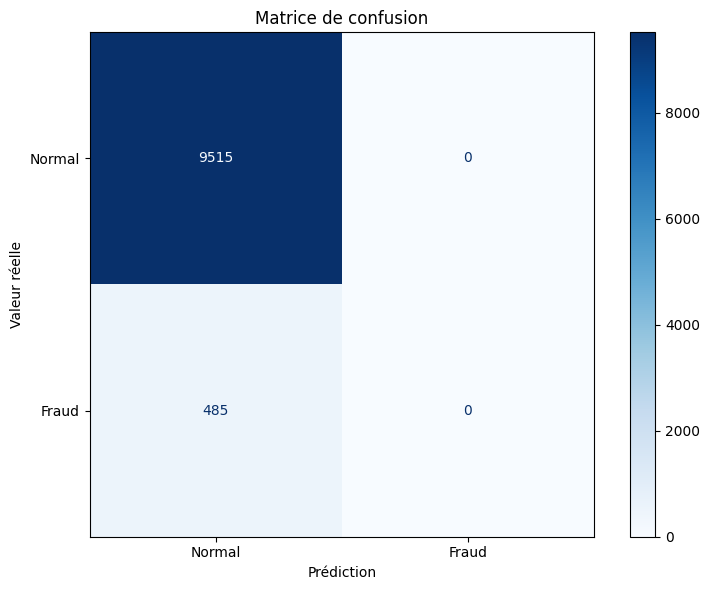

<Figure size 640x480 with 0 Axes>

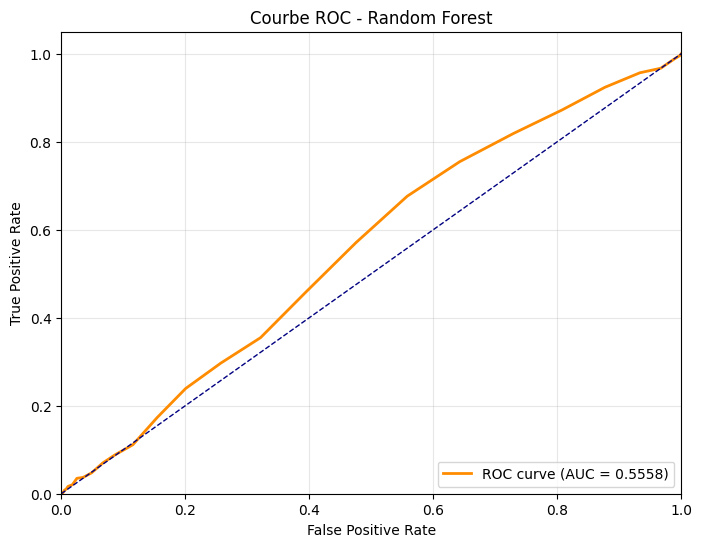

In [49]:
print("=" * 60)
print("PRESENTATION DES RESULTATS")
print("=" * 60)

# Affichage de la matrice de confusion pour visualiser les erreurs de classification.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=True)
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.tight_layout()
plt.show()
plt.tight_layout()

## Courbe ROC-AUC
# La courbe ROC évalue la capacité du modèle à séparer les deux classes
# pour différents seuils de décision.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Tracer la courbe ROC et afficher l'AUC.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [50]:
# sauvegarder la courbe roc dans un fichier pour une analyse ultérieure.
roc_data = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "thresholds": thresholds
})
roc_data.to_csv("../results/rf_roc.csv", index=False)

In [52]:
# sauvegarder la matrix de confusion dans un fichier pour une analyse ultérieure.
cm_df = pd.DataFrame(cm, index=["Normal", "Fraud"], columns=["Normal", "Fraud"])
pd.DataFrame(cm).to_csv(
    "../results/rf_cm.csv",
    index=False,
    header=False
)